# 05 · E2: substrate transfer of the closed level

**Test of the "independent of realization" half of claim C2.** If the closed level L* found in E1 is software, then the same parameters run on a different substrate should produce the same interventional responses. Its failure mode is measurable: if macro behavior diverges with numerical precision (a positive Lyapunov exponent), the "software" cannot be separated from its physics.

This notebook takes **your fitted L* models from Notebook 04**, one per cross-validation fold (`results/e1_checkpoints*/`), and runs each on:

| substrate | implementation | what changes |
|---|---|---|
| `ref` | JAX, Euler, dt = 0.2 s, float32 | the substrate it was fitted on |
| `euler64` | NumPy, Euler, dt = 0.2 s, float64 | precision only; must reproduce `ref` (sanity check) |
| `ode` | NumPy, RK4, dt = 0.02 s, float64 | continuous-time limit: does the fit depend on its time step? |
| `brian2` | Brian2 (numpy code generation), RK4, dt = 0.02 s | an independent simulator, code generator and integrator |
| `fixed` | integer weights, fixed-point state, sigmoid look-up table | neuromorphic constraints, swept over bit widths |

**Plus:**
* **Degeneracy** (Prinz et al. 2004): the five fold models were fitted independently. Do their parameters differ while their behavior agrees?
* **Macro-level Lyapunov exponent**, at rest and under random pulse drive.

**Measures.** `gap/noise` is the squared difference from `ref` on observed pairs, divided by the measurement noise of those pairs; values < 1 mean the experiment could not tell the substrates apart. ΔFEVE is the change in held-out FEVE (the same held-out pairs as in E1).

**Scope.** E1 in `laptop` mode gave L* = L1 on a 120-neuron sub-network, so E2 here is preliminary in the same sense. Notebook 04 also showed that L0 predicts about as well as L1. A result of "L1 is substrate-invariant" therefore says that *this fitted description* transfers; it does not show that L1 is the uniquely right level.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, pickle, hashlib, datetime, numpy as np, matplotlib.pyplot as plt, jax
from closurebench import data as D, ladder as lad, metrics as M, substrates as SB
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG          # smoke reuses the laptop fits if present
e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
e1_plan = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))
LSTAR = e1_result["L_star"]
print("E1 result used:", f"E1_result{E1_TAG}.json", "| L* =", LSTAR)
assert LSTAR == "L1", "substrates.py currently implements L1; extend substrates._deriv for other rungs"

# rebuild exactly the E1 dataset and folds
c = e1_plan["config"]
ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
if c["n_neurons"] < ds.N:
    mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
    ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
folds = M.kfold_pairs(ds, c["k_folds"], c["fold_seed"])
ck = os.path.join(RESULTS, f"e1_checkpoints{E1_TAG}")
models = [pickle.load(open(os.path.join(ck, f"fold{f}_{LSTAR}_final.pkl"), "rb"))["params"] for f in range(c["k_folds"])]
COLS = np.arange(ds.S) if MODE != "smoke" else np.arange(10)
FOLDS = range(len(models)) if MODE != "smoke" else range(2)
print(ds.summary()); print(f"{len(models)} fitted {LSTAR} models; simulating {len(COLS)} stimuli each")

E1 result used: E1_result_laptop.json | L* = L1
Dataset: N=120 neurons, S=120 stimulated neurons, strains=('wt', 'unc31')
  chemical synapses: 1086  gap-junction pairs: 277  peptidergic pairs: 9125
  signs: +163 / -200 / unknown 726 (on existing synapses)
  wt: 13706 observed pairs, median trials 5
  unc31: 6199 observed pairs, median trials 1
5 fitted L1 models; simulating 120 stimuli each


## 1 · Pre-registration of the E2 decision rule

Write this before running §2.

* **Substrate invariance** holds if, for every fold model and every substrate in {`euler64`, `ode`, `brian2`}, gap/noise < 0.1 and |ΔFEVE| < 0.05.
* **Neuromorphic transfer:** report the lowest bit widths that meet the same two thresholds.
* **Separability from the physics** requires the largest Lyapunov exponent to be < 0 at rest and under drive, for every fold model.

In [3]:
prereg = os.path.join(RESULTS, f"E2_preregistration{TAG}.json")
plan = {"experiment": "E2 substrate transfer", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "uses": {"E1_result": f"E1_result{E1_TAG}.json", "L_star": LSTAR, "n_models": len(models)},
        "substrates": ["euler64", "ode (RK4 dt=0.02)", "brian2 (numpy, RK4 dt=0.02)"],
        "invariance_rule": "for every fold model and substrate: gap/noise < 0.1 and |dFEVE(held-out)| < 0.05",
        "neuromorphic_rule": "report minimal (w_bits, frac_bits, lut_bits) meeting the same thresholds",
        "separability_rule": "largest Lyapunov exponent < 0 at rest and under random pulse drive, every fold model"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Existing registration ( 2026-10-05T14:36:07.455332+00:00 ) used unchanged.


## 2 · Run every fold model on every substrate

In [4]:
import time
HAVE_BRIAN2 = True
try:
    SB.import_brian2()
except ImportError as err:   # not installed, or Brian2 2.9 with NumPy >= 2.4 (see message)
    HAVE_BRIAN2 = False; print(f"Skipping the Brian2 substrate: {err}")
rows, R_all, eff_all = [], {}, []
for f in FOLDS:
    p = jax.tree_util.tree_map(jax.numpy.asarray, models[f])
    e = SB.effective_params(LSTAR, p, st, COLS); eff_all.append(e)
    R = {"ref": np.asarray(lad.predict(LSTAR, p, st, ds.stim[COLS], ds.strains, cfg, COLS))[0]}
    t0 = time.time()
    R["euler64"] = SB.simulate_numpy(e, ds.stim[COLS], cfg, "euler")
    R["ode"] = SB.simulate_numpy(e, ds.stim[COLS], cfg, "rk4", dt=0.02)
    if HAVE_BRIAN2:
        R["brian2"] = SB.simulate_brian2(e, ds.stim[COLS], cfg, dt=0.02)
    R_all[f] = R
    f_ref = SB.feve_on(R["ref"], ds, COLS, folds[f])
    for name, Rs in R.items():
        rows.append(dict(fold=f, substrate=name, gap=SB.substrate_gap(Rs, R["ref"], ds, COLS),
                         feve=SB.feve_on(Rs, ds, COLS, folds[f]), dfeve=SB.feve_on(Rs, ds, COLS, folds[f]) - f_ref))
    print(f"fold {f}: done in {time.time() - t0:.0f} s")
print(f"\n{'fold':>4s} {'substrate':10s} {'gap/noise':>10s} {'held-out FEVE':>14s} {'dFEVE':>8s}")
for r in rows:
    print(f"{r['fold']:4d} {r['substrate']:10s} {r['gap']:10.4f} {r['feve']:14.3f} {r['dfeve']:+8.3f}")
subs = [s for s in ["euler64", "ode", "brian2"] if any(r["substrate"] == s for r in rows)]
invariant = all(r["gap"] < 0.1 and abs(r["dfeve"]) < 0.05 for r in rows if r["substrate"] in subs)
print(f"\nRegistered rule -> substrate invariance across {subs}: {invariant}")

fold 0: done in 9 s
fold 1: done in 10 s
fold 2: done in 9 s
fold 3: done in 10 s
fold 4: done in 12 s

fold substrate   gap/noise  held-out FEVE    dFEVE
   0 ref            0.0000          0.254   +0.000
   0 euler64        0.0000          0.253   -0.000
   0 ode            0.0013          0.245   -0.008
   0 brian2         0.0012          0.245   -0.008
   1 ref            0.0000          0.279   +0.000
   1 euler64        0.0000          0.279   -0.000
   1 ode            0.0015          0.281   +0.002
   1 brian2         0.0014          0.280   +0.001
   2 ref            0.0000          0.288   +0.000
   2 euler64        0.0000          0.287   -0.000
   2 ode            0.0015          0.266   -0.022
   2 brian2         0.0015          0.266   -0.022
   3 ref            0.0000          0.325   +0.000
   3 euler64        0.0000          0.325   -0.000
   3 ode            0.0013          0.321   -0.004
   3 brian2         0.0012          0.321   -0.004
   4 ref            0.0000   

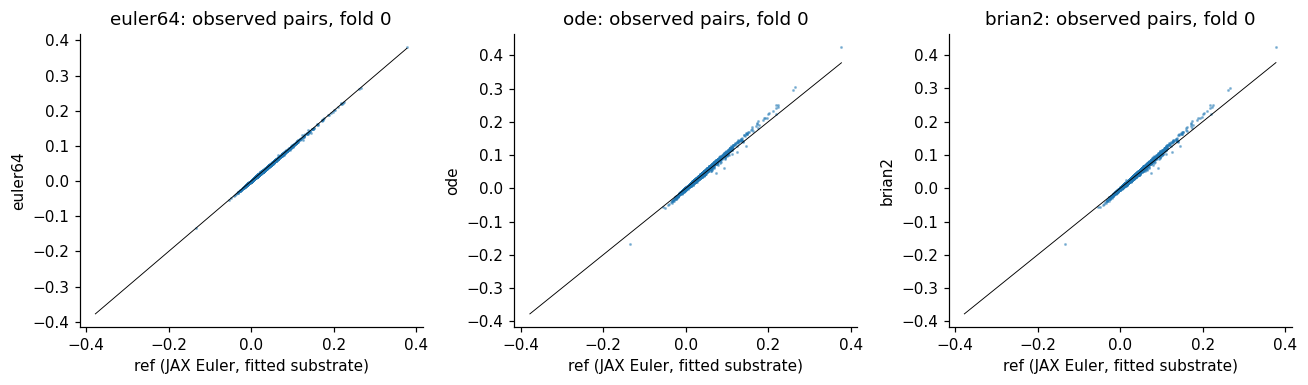

In [5]:
fig, ax = plt.subplots(1, len(subs), figsize=(4 * len(subs), 3.6), squeeze=False)
R0 = R_all[list(FOLDS)[0]]; m = ds.mask()[0][:, COLS]
for a, s in zip(ax[0], subs):
    a.plot(R0["ref"][m], R0[s][m], ".", ms=2, alpha=0.4)
    lim = np.abs(R0["ref"][m]).max(); a.plot([-lim, lim], [-lim, lim], "k-", lw=0.6)
    a.set_xlabel("ref (JAX Euler, fitted substrate)"); a.set_ylabel(s); a.set_title(f"{s}: observed pairs, fold 0")
plt.tight_layout(); plt.show()

## 3 · Neuromorphic constraints: which precision does the software need?

Weight precision, state precision and the activation look-up table are swept one at a time, then in combination. Bars show gap/noise; the dashed line is the 0.1 threshold. Bar colour shows the verdict on **both** registered criteria (gap/noise < 0.1 *and* |ΔFEVE| < 0.05), so a bar can sit below the line and still be red.

w      weights  8 b, state 16 frac b, LUT 16 b: gap/noise 0.0024  dFEVE -0.003  OK
w      weights  6 b, state 16 frac b, LUT 16 b: gap/noise 0.0343  dFEVE -0.085  fails
w      weights  4 b, state 16 frac b, LUT 16 b: gap/noise 0.0836  dFEVE -0.211  fails
frac   weights 16 b, state 12 frac b, LUT 16 b: gap/noise 0.0006  dFEVE +0.010  OK
frac   weights 16 b, state 10 frac b, LUT 16 b: gap/noise 0.0773  dFEVE +0.031  OK
frac   weights 16 b, state  8 frac b, LUT 16 b: gap/noise 0.6852  dFEVE -0.703  fails
lut    weights 16 b, state 16 frac b, LUT 12 b: gap/noise 0.0000  dFEVE -0.001  OK
lut    weights 16 b, state 16 frac b, LUT 10 b: gap/noise 0.0009  dFEVE -0.001  OK
lut    weights 16 b, state 16 frac b, LUT  8 b: gap/noise 0.0656  dFEVE -0.031  OK
combo  weights  8 b, state 12 frac b, LUT 10 b: gap/noise 0.0090  dFEVE +0.015  OK
combo  weights  8 b, state 10 frac b, LUT 10 b: gap/noise 0.1050  dFEVE -0.020  fails
combo  weights  6 b, state 12 frac b, LUT 10 b: gap/noise 0.0279  dFEVE -0.

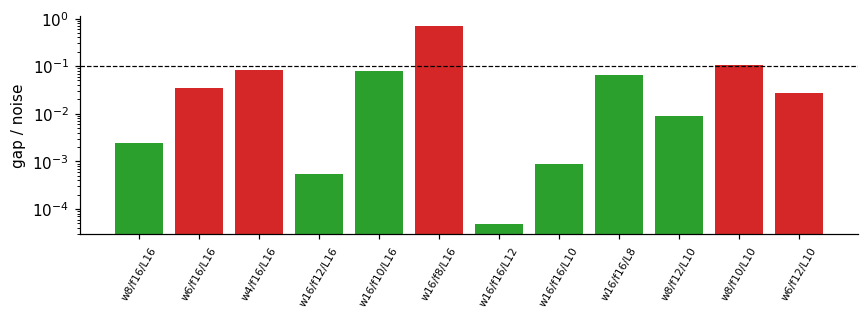

lowest passing combination: {'kind': 'combo', 'w': 8, 'frac': 12, 'lut': 10, 'gap': 0.008979127047664641, 'dfeve': np.float64(0.014945216853840981)}


In [6]:
f0 = list(FOLDS)[0]; e = eff_all[0]; R_ref = R_all[f0]["ref"]
configs = [("w", wb, 16, 16) for wb in (8, 6, 4)] + [("frac", 16, fb, 16) for fb in (12, 10, 8)] + \
          [("lut", 16, 16, lb) for lb in (12, 10, 8)] + [("combo", 8, 12, 10), ("combo", 8, 10, 10), ("combo", 6, 12, 10)]
q_rows = []
for kind, wb, fb, lb in configs:
    R = SB.simulate_fixed_point(e, ds.stim[COLS], cfg, w_bits=wb, frac_bits=fb, lut_bits=lb)
    q_rows.append(dict(kind=kind, w=wb, frac=fb, lut=lb, gap=SB.substrate_gap(R, R_ref, ds, COLS),
                       dfeve=SB.feve_on(R, ds, COLS, folds[f0]) - SB.feve_on(R_ref, ds, COLS, folds[f0])))
ok = lambda r: r["gap"] < 0.1 and abs(r["dfeve"]) < 0.05
for r in q_rows:
    print(f"{r['kind']:6s} weights {r['w']:2d} b, state {r['frac']:2d} frac b, LUT {r['lut']:2d} b: "
          f"gap/noise {r['gap']:.4f}  dFEVE {r['dfeve']:+.3f}  {'OK' if ok(r) else 'fails'}")
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(q_rows)), [r["gap"] for r in q_rows], color=["tab:green" if ok(r) else "tab:red" for r in q_rows])
ax.axhline(0.1, ls="--", c="k", lw=0.8); ax.set_yscale("log"); ax.set_ylabel("gap / noise")
ax.set_xticks(range(len(q_rows))); ax.set_xticklabels([f"w{r['w']}/f{r['frac']}/L{r['lut']}" for r in q_rows], rotation=60, fontsize=7)
plt.tight_layout(); plt.show()
passing = [r for r in q_rows if r["kind"] == "combo" and ok(r)]
print("lowest passing combination:", min(passing, key=lambda r: r["w"] + r["frac"] + r["lut"]) if passing else "none")

## 4 · Degeneracy: different parameters, same behavior?

Each fold model was fitted to a different 80% of the data. High response correlation together with low parameter correlation would be Prinz-style degeneracy: the "software" is the behavior, not one parameter set.

In [7]:
if len(eff_all) > 1:
    dg = SB.degeneracy(eff_all, [R_all[f]["ref"] for f in FOLDS])
    print(f"{'quantity':10s} {'mean r':>7s} {'min':>6s} {'max':>6s}   (pairwise correlation across fold models)")
    for k, (mu, lo, hi) in dg.items():
        print(f"{k:10s} {mu:7.3f} {lo:6.3f} {hi:6.3f}")

quantity    mean r    min    max   (pairwise correlation across fold models)
W            0.939  0.925  0.968
G            0.967  0.946  0.998
bias         0.537  0.381  0.847
theta        0.449  0.184  0.804
tau          0.117 -0.047  0.344
responses    0.863  0.843  0.907


## 5 · Macro-level Lyapunov exponent

Benettin method, RK4 in float64, 300 s per condition. Negative values mean perturbations, including those caused by limited numerical precision, die out.

In [8]:
T_LY = 300.0 if MODE != "smoke" else 50.0
lyap = {f: (SB.lyapunov(eff_all[i], T=T_LY, drive="none"), SB.lyapunov(eff_all[i], T=T_LY, drive="pulses", seed=f))
        for i, f in enumerate(FOLDS)}
for f, (lr, ld) in lyap.items():
    print(f"fold {f}: lambda_max at rest {lr:+.3f} /s, under pulse drive {ld:+.3f} /s")
separable = all(v < 0 for pair in lyap.values() for v in pair)
print("Registered rule -> separable from numerical physics:", separable)

fold 0: lambda_max at rest -0.090 /s, under pulse drive -0.140 /s
fold 1: lambda_max at rest -0.084 /s, under pulse drive -0.130 /s
fold 2: lambda_max at rest -0.111 /s, under pulse drive -0.159 /s
fold 3: lambda_max at rest -0.090 /s, under pulse drive -0.137 /s
fold 4: lambda_max at rest -0.098 /s, under pulse drive -0.142 /s
Registered rule -> separable from numerical physics: True


In [9]:
out = {"preregistration": os.path.basename(prereg), "L_star": LSTAR, "invariant": bool(invariant),
       "rows": rows, "neuromorphic": q_rows, "separable": bool(separable),
       "lyapunov": {str(f): list(v) for f, v in lyap.items()},
       "degeneracy": SB.degeneracy(eff_all, [R_all[f]["ref"] for f in FOLDS]) if len(eff_all) > 1 else None}
json.dump(out, open(os.path.join(RESULTS, f"E2_result{TAG}.json"), "w"), indent=2, default=float)
print(json.dumps({k: out[k] for k in ["L_star", "invariant", "separable"]}, indent=1))

{
 "L_star": "L1",
 "invariant": true,
 "separable": true
}


## 6 · Reading the result

| Pattern | Meaning for C2 |
|---|---|
| invariant across `euler64`, `ode`, `brian2`, and λ < 0 | the fitted level transfers between simulators and integrators: software-like *with respect to numerical substrate* |
| invariant only with high-precision state | the computation lives in small activity deviations; a neuromorphic port needs that precision |
| ODE/Brian2 differ from `ref` | the fit exploits the coarse Euler step: what was fitted is partly an artifact of its substrate |
| λ > 0 | macro behavior depends on precision: no separable software |

**Limits.** All substrates here are *numerical*: they share the equations and change only how those are executed. A stronger E2 changes the *equations* while keeping the level, e.g. a spiking realization of L1 or a Jaxley conductance version, and asks whether the fitted interventional responses survive. That is the next extension: Notebook 07 (E2b) in the roadmap of Notebook 00.

---

### Result on the `laptop` E1 fits (5 fold models of L1, 120 neurons, all 120 stimuli; outputs above, saved to `results/E2_result_laptop.json`)

| test | result | registered verdict |
|---|---|---|
| `euler64` vs `ref` | gap/noise 0.0000, dFEVE 0.000 | — (sanity check passed) |
| `ode` (RK4) vs `ref` | gap/noise 0.0012–0.0015, dFEVE −0.022 to +0.002 | **invariant** |
| `brian2` vs `ref` | gap/noise 0.0012–0.0015, dFEVE −0.022 to +0.001 | **invariant** |
| neuromorphic, lowest passing combination tested | 8-bit weights, 12 fractional bits of state, 10-bit LUT (gap/noise 0.009, ΔFEVE +0.015) | fail: 6-bit weights (ΔFEVE −0.085), 8 fractional bits of state (ΔFEVE −0.70); 8-bit weights + 10-bit state + 10-bit LUT fails narrowly (gap/noise 0.105) |
| Lyapunov exponent (5 folds) | rest −0.084 to −0.111 /s; driven −0.130 to −0.159 /s | **separable** |
| degeneracy (r across folds) | W 0.94, G 0.97, responses 0.86; bias 0.54, θ 0.45, τ 0.12 | — |

**Interpretation:**

* The fitted L1 is software *with respect to numerical substrate*. Brian2 and an independent RK4 integrator reproduce it far below measurement noise. The fit does not exploit the coarse Euler step, and perturbations decay.
* The precision demands show that the computation lives in small activity deviations around rest. State precision is the binding constraint: 8 fractional bits collapse held-out accuracy (ΔFEVE −0.70); 10 bits pass on their own but fail when combined with 8-bit weights and a 10-bit LUT; 12 bits pass with margin. Weights tolerate 8 bits but not 6. This fits with Notebook 04, where the linear L0 predicts as well as L1: the network is used in a near-linear regime.
* **ΔFEVE is the stricter criterion.** With 6-bit weights the gap is only 0.034 of the noise, yet held-out FEVE drops by 0.085. Most of the measured variance is noise, so a difference that is small relative to the noise can still be large relative to the *explainable* signal the model captures. This is why the rule requires both criteria.
* **Degeneracy is partial.** Wiring weights are reproducible across folds, while per-neuron time constants and thresholds are not. Part of the weight agreement reflects the shared connectome-derived initialization and its regularizer, so read W/G correlations as an upper bound. Amplitude data constrain the *gains* of the computation but leave its *timing* free, the same blind spot that hid L2 in Notebook 02.